# ***Bank Loan Analysis Report***

### Importing Libraries and Files

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import plotly.express as px

In [ ]:
df = pd.read_excel(C:\Users\RASID\Downloads)

### ***Metadeta of the Data***

In [3]:
print('No of Rows:', df.shape[0])

No of Rows: 38576


In [4]:
print('No of Columns:', df.shape[1])

No of Columns: 24


### Data Types

In [5]:
df.dtypes

id                                int64
address_state                       str
application_type                    str
emp_length                          str
emp_title                        object
grade                               str
home_ownership                      str
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
loan_status                         str
next_payment_date        datetime64[us]
member_id                         int64
purpose                             str
sub_grade                           str
term                                str
verification_status                 str
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

### Total Loan Applications:

In [6]:
Total_Loan_Applications = df['id'].count()

print('Total Loan Applications:', Total_Loan_Applications)

Total Loan Applications: 38576


### MTD Total Loan Applications:

In [7]:
latest_issue_dt = df['issue_date'].max()

latest_year = latest_issue_dt.year
latest_month = latest_issue_dt.month

mtd_data = df[
    (df['issue_date'].dt.year == latest_year) &
    (df['issue_date'].dt.month == latest_month)
]

mtd_loan_application = mtd_data['id'].count()

print(f"MTD Loan Applications (for {latest_issue_dt.strftime('%B %Y')}): {mtd_loan_application}")


MTD Loan Applications (for December 2021): 4314


### Total Funded Amount

In [8]:
Total_Funded_Amount = df['loan_amount'].sum()

Total_Funded_Amount_millions = Total_Funded_Amount / 1_000_000

print(f"Total Funded Amount: ${Total_Funded_Amount_millions:.2f}M")


Total Funded Amount: $435.76M


### MTD Total Funded Amount

In [9]:
latest_issue_dt = df['issue_date'].max()

latest_year = latest_issue_dt.year
latest_month = latest_issue_dt.month

mtd_data = df[
    (df['issue_date'].dt.year == latest_year) &
    (df['issue_date'].dt.month == latest_month)
]

mtd_total_funded_amount = mtd_data['loan_amount'].sum()
mtd_total_funded_amount_m = mtd_total_funded_amount / 1_000_000

print(
    f"MTD Total Funded Amount (for {latest_issue_dt.strftime('%B %Y')}): "
    f"${mtd_total_funded_amount_m:.2f}M"
)


MTD Total Funded Amount (for December 2021): $53.98M


### Total Amount Received: 

In [10]:
Total_Amount_Received = df['total_payment'].sum()

Total_Amount_Received_millions = Total_Amount_Received / 1_000_000

print(f"Total Amount Received:  ${Total_Amount_Received_millions:.2f}M")


Total Amount Received:  $473.07M


### MTD Total_Amount_Received

In [11]:
latest_issue_dt = df['issue_date'].max()

latest_year = latest_issue_dt.year
latest_month = latest_issue_dt.month

mtd_data = df[
    (df['issue_date'].dt.year == latest_year) &
    (df['issue_date'].dt.month == latest_month)
]

mtd_Total_Amount_Received = mtd_data['total_payment'].sum()
Total_Amount_Received_millions = mtd_Total_Amount_Received / 1_000_000

print(
    f"MTD Total Amount Received (for {latest_issue_dt.strftime('%B %Y')}): "
    f"${Total_Amount_Received_millions:.2f}M"
)


MTD Total Amount Received (for December 2021): $58.07M


### Average Interest Rate

In [12]:
avg_int_rate = df['int_rate'].mean()*100

print(f"Average Interest Rate: {avg_int_rate:.2f}%")


Average Interest Rate: 12.05%


### MTD Average Interest Rate:

In [13]:
mtd_avg_int_rate = mtd_data['int_rate'].mean()*100

print(
    f"MTD Average Interest Rate (for {latest_issue_dt.strftime('%B %Y')}): "
    f"{mtd_avg_int_rate:.2f}%"
)


MTD Average Interest Rate (for December 2021): 12.36%


### Average Debt-to-Income Ratio (DTI)

In [14]:
avg_dti = df['dti'].mean()*100

print(f"Average Debt-to-Income Ratio (DTI): {avg_dti:.2f}%")


Average Debt-to-Income Ratio (DTI): 13.33%


### Good Loan Metrix

In [15]:
good_loans = df[df['loan_status'].isin(['Fully Paid', 'Current'])]

# total_loan_applications = df['id'].count()

good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_m = good_loan_funded_amount / 1_000_000
good_loan_received_m = good_loan_received / 1_000_000

good_loan_percentage = (good_loan_applications / Total_Loan_Applications) * 100

print("GOOD LOAN KPIs")
print(f"Applications: {good_loan_applications}")
print(f"Application %: {good_loan_percentage:.2f}%")
print(f"Funded Amount: ${good_loan_funded_amount_m:.2f}M")
print(f"Amount Received: ${good_loan_received_m:.2f}M")


GOOD LOAN KPIs
Applications: 33243
Application %: 86.18%
Funded Amount: $370.22M
Amount Received: $435.79M


### Bad Loan Metrix

In [17]:
bad_loans = df[df['loan_status'].isin(['Charged Off', 'Default'])]

bad_loan_applications = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_received = bad_loans['total_payment'].sum()

bad_loan_funded_amount_m = bad_loan_funded_amount / 1_000_000
bad_loan_received_m = bad_loan_received / 1_000_000

bad_loan_percentage = (bad_loan_applications / Total_Loan_Applications) * 100

print("\nBAD LOAN KPIs")
print(f"Applications: {bad_loan_applications}")
print(f"Application %: {bad_loan_percentage:.2f}%")
print(f"Funded Amount: ${bad_loan_funded_amount_m:.2f}M")
print(f"Amount Received: ${bad_loan_received_m:.2f}M")



BAD LOAN KPIs
Applications: 5333
Application %: 13.82%
Funded Amount: $65.53M
Amount Received: $37.28M


### ***Charts Requirements***

### 1️⃣ Monthly Trends (Line / Area Chart)

In [18]:
# Step 1 — Create Year–Month column


df['issue_date'] = pd.to_datetime(df['issue_date'])
df['issue_month'] = df['issue_date'].dt.to_period('M').astype(str)

# Step 2 — Aggregate metrics by month


monthly_kpis = df.groupby('issue_month').agg(
    total_applications=('id', 'count'),
    total_funded=('loan_amount', 'sum'),
    total_received=('total_payment', 'sum')
).reset_index()


# Convert to millions:

monthly_kpis['total_funded_m'] = monthly_kpis['total_funded'] / 1_000_000
monthly_kpis['total_received_m'] = monthly_kpis['total_received'] / 1_000_000


# Sort by time:

monthly_kpis['issue_month'] = pd.to_datetime(monthly_kpis['issue_month'])
monthly_kpis = monthly_kpis.sort_values('issue_month')
monthly_kpis['month_name'] = monthly_kpis['issue_month'].dt.strftime('%b')


### Total Funded Amount and Total Amount Received

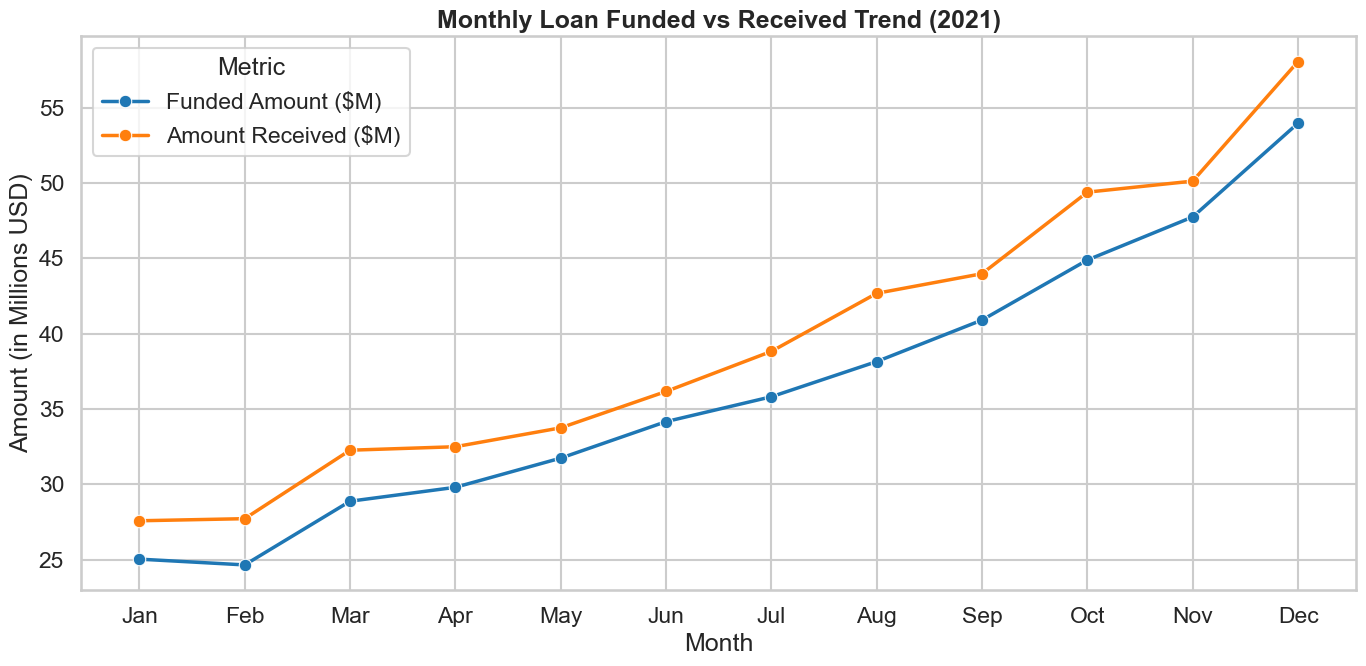

In [19]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(14,7))

sns.lineplot(
    data=monthly_kpis,
    x='month_name',
    y='total_funded_m',
    marker='o',
    linewidth=2.5,
    label='Funded Amount ($M)'
)

sns.lineplot(
    data=monthly_kpis,
    x='month_name',
    y='total_received_m',
    marker='o',
    linewidth=2.5,
    label='Amount Received ($M)'
)

plt.title("Monthly Loan Funded vs Received Trend (2021)", fontsize=18, weight='bold')
plt.xlabel("Month")
plt.ylabel("Amount (in Millions USD)")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


### Regional Analysis (State Bar Chart)

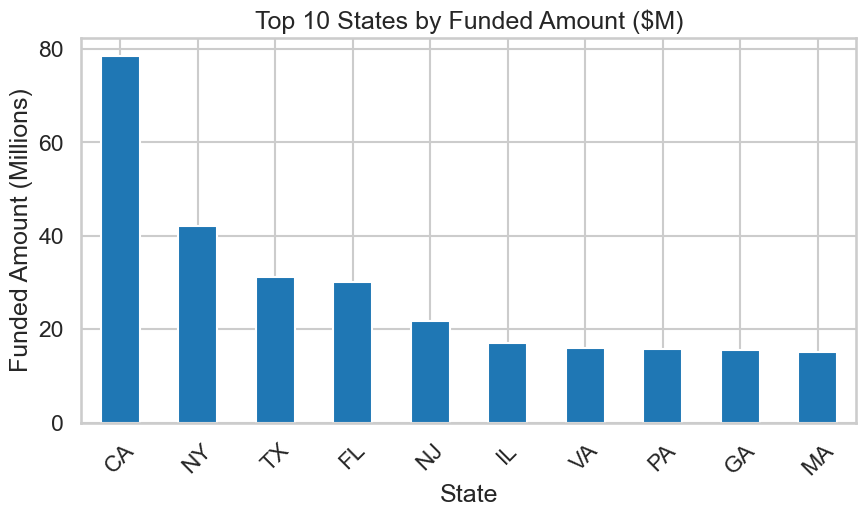

In [20]:
state_data = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=False).head(10) / 1_000_000

plt.figure(figsize=(10,5))
state_data.plot(kind='bar')
plt.title("Top 10 States by Funded Amount ($M)")
plt.ylabel("Funded Amount (Millions)")
plt.xlabel("State")
plt.xticks(rotation=45)
plt.show()


### Loan Term Donut Chart

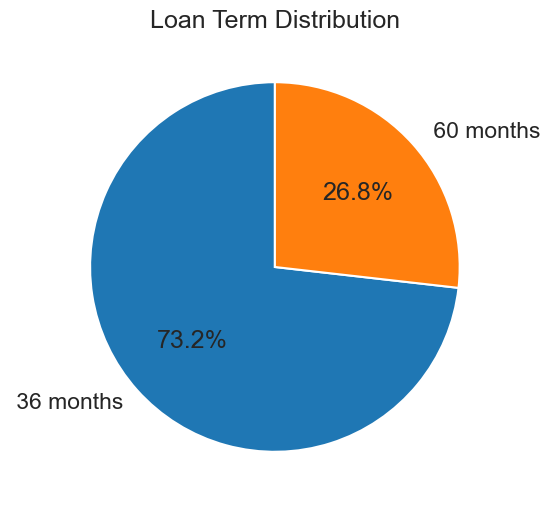

In [21]:
term_counts = df['term'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(term_counts, labels=term_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Loan Term Distribution")
plt.show()


### Employee Length Bar Chart

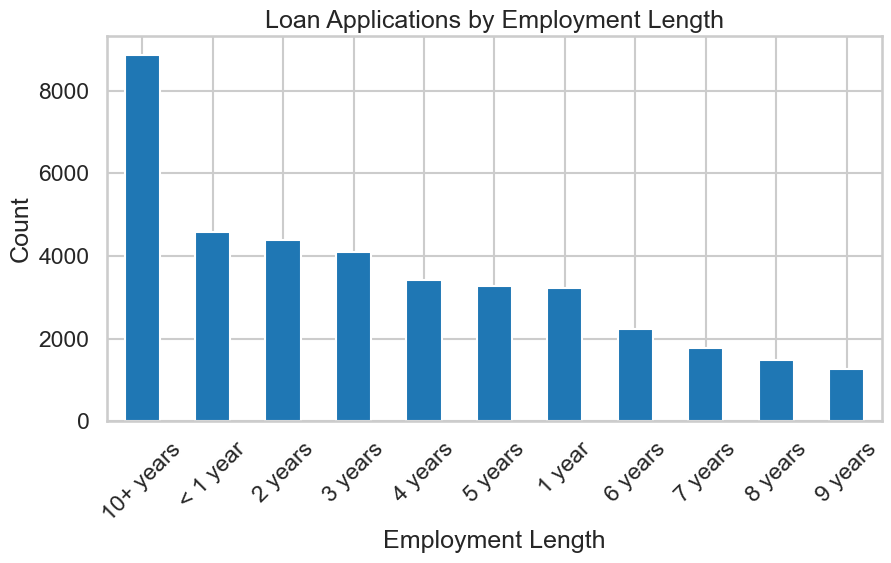

In [22]:
emp_data = df['emp_length'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,5))
emp_data.plot(kind='bar')
plt.title("Loan Applications by Employment Length")
plt.xlabel("Employment Length")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


### Loan Purpose Breakdown

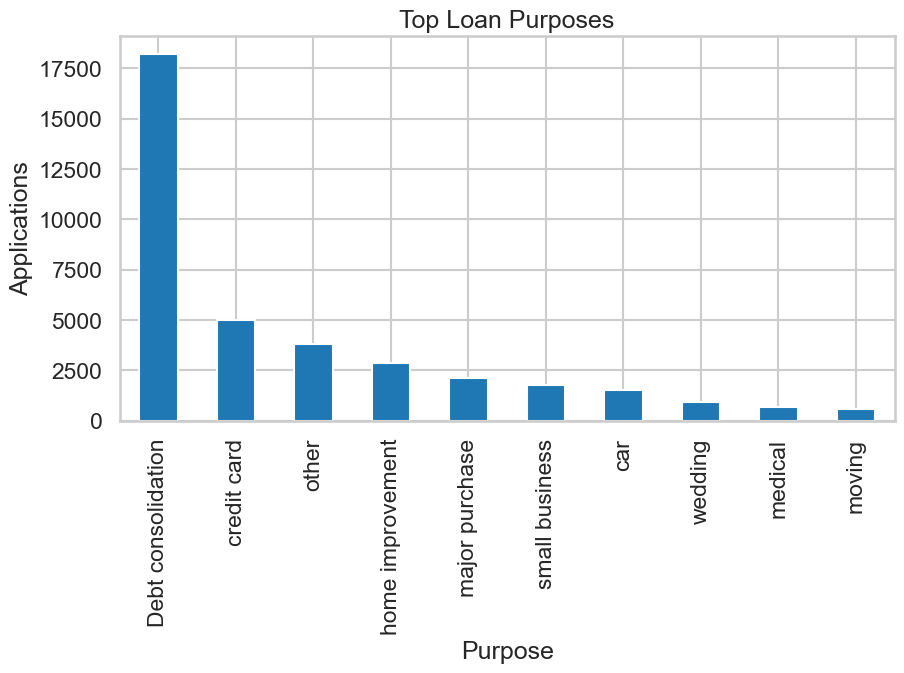

In [23]:
purpose_data = df['purpose'].value_counts().head(10)

plt.figure(figsize=(10,5))
purpose_data.plot(kind='bar')
plt.title("Top Loan Purposes")
plt.xlabel("Purpose")
plt.ylabel("Applications")
plt.show()


### Home Ownership Heatmap

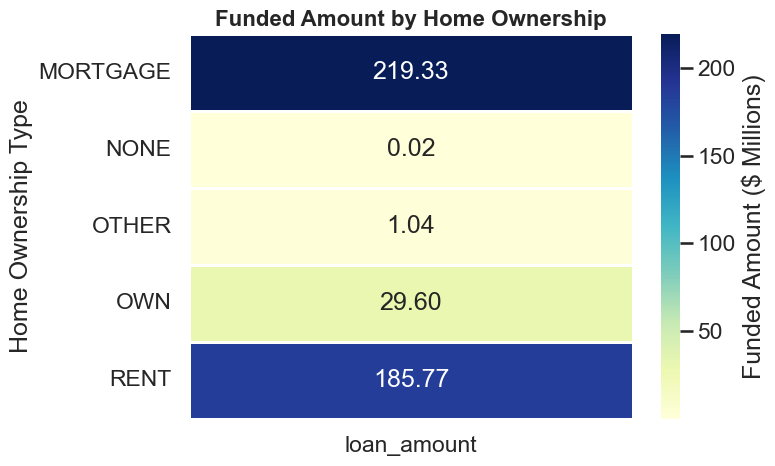

In [24]:
sns.set_style("white")
sns.set_context("talk")

home_data = pd.pivot_table(
    df,
    values='loan_amount',
    index='home_ownership',
    aggfunc='sum'
) / 1_000_000

plt.figure(figsize=(8,5))

sns.heatmap(
    home_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'Funded Amount ($ Millions)'}
)

plt.title("Funded Amount by Home Ownership", fontsize=16, weight='bold')
plt.xlabel("")
plt.ylabel("Home Ownership Type")
plt.tight_layout()
plt.show()


# 📌 Project Conclusion & Insights

## 🔎 Key Findings

- The overall loan portfolio shows strong performance with a high percentage of **Good Loans (Fully Paid & Current)** compared to Bad Loans.
- Monthly trend analysis highlights consistent funding activity, with noticeable variation in total amount received.
- Certain states contribute significantly higher funded amounts, indicating regional concentration of lending.
- The majority of loans are concentrated in specific employment length categories and loan purposes.
- Home ownership status plays a visible role in total funded volume.

---

## 📊 Risk & Performance Observations

- The Bad Loan percentage indicates manageable default risk but still requires monitoring.
- Interest rate and DTI averages suggest moderate borrower risk exposure.
- Comparing Funded vs Received amounts helps evaluate portfolio recovery efficiency.

---

## 💡 Business Recommendations

- Focus more on high-performing states for strategic expansion.
- Apply stricter credit screening in segments contributing to higher default rates.
- Analyze borrower profile (DTI + Employment Length + Purpose) for predictive risk modeling.
- Implement advanced analytics (such as classification models) to predict loan defaults.

---

## 🚀 Future Enhancements

- Build a machine learning model to predict Good vs Bad loans.
- Create an interactive dashboard using Plotly or Power BI.
- Perform deeper correlation analysis between borrower attributes and default risk.
- Add year-over-year trend comparison.

---

## 👨‍💻 Project Developed By

**IZAAN SARWAR**  
Aspiring Data Analyst  
Skilled in Python | SQL | Power BI | Excel